In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключаем функции fft, fftfreq
from scipy.fft import fft, fftfreq

# подключение библиотеки
import matplotlib.pyplot as plt

Ts * F0 =  10.0


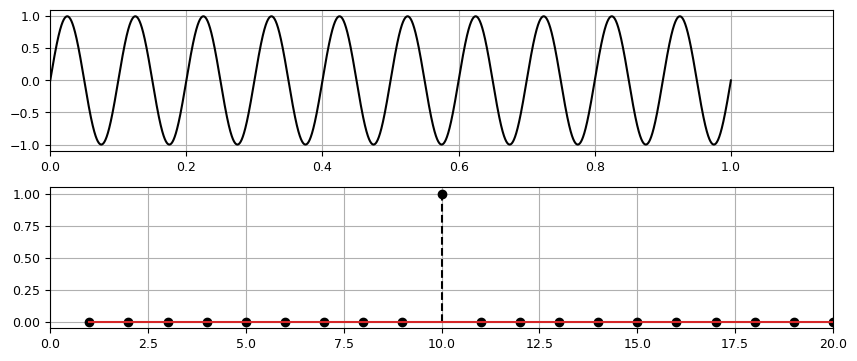

Ts * F0 =  10.1


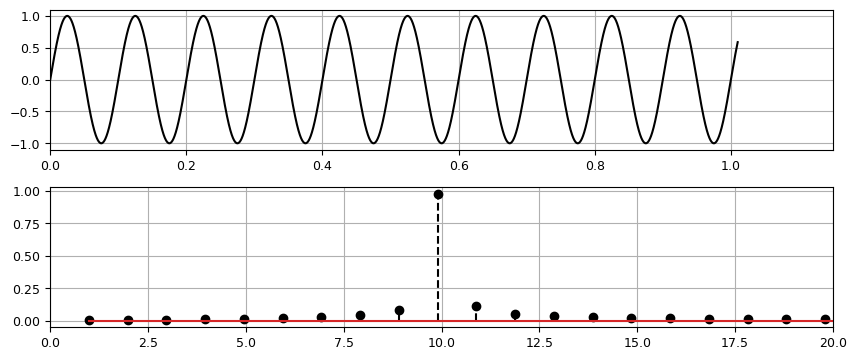

Ts * F0 =  10.2


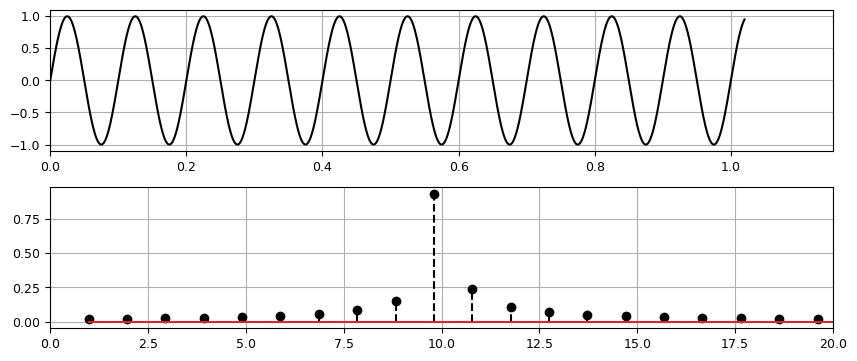

Ts * F0 =  10.3


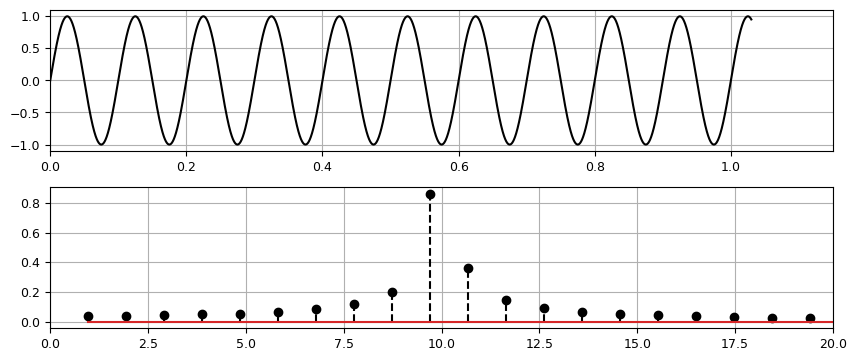

Ts * F0 =  10.4


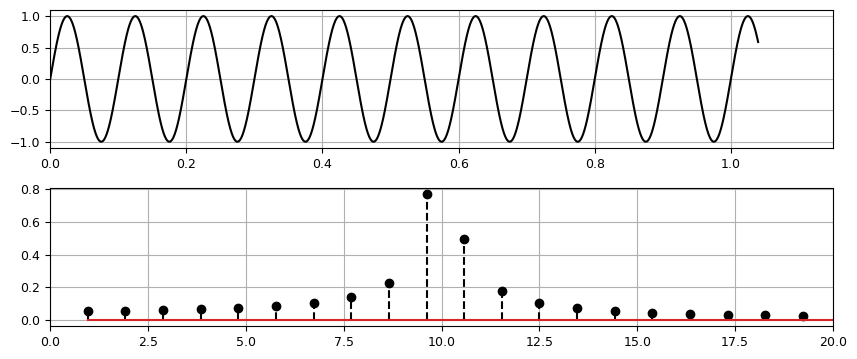

Ts * F0 =  10.5


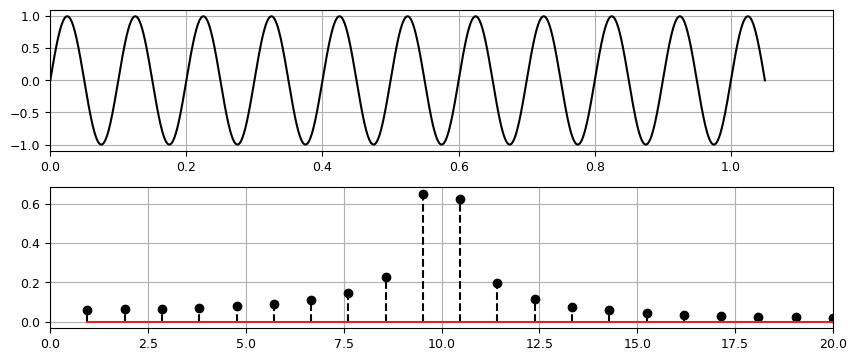

Ts * F0 =  10.600000000000001


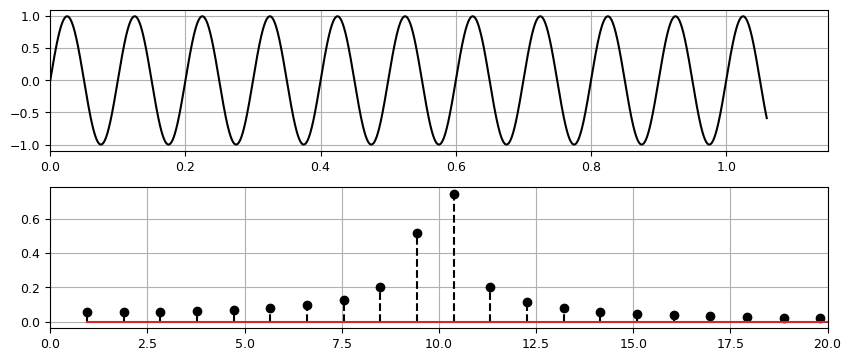

Ts * F0 =  10.700000000000001


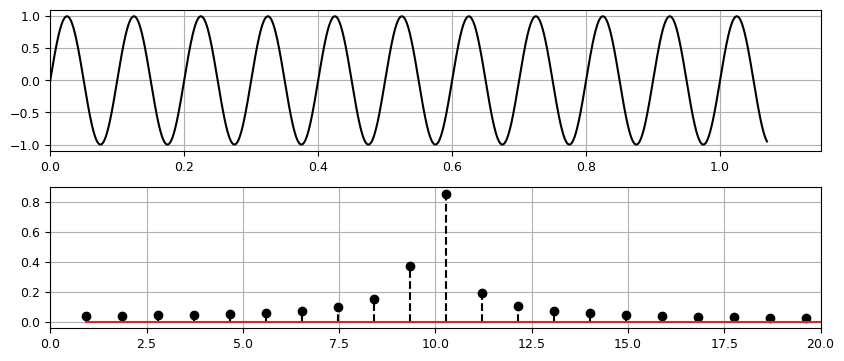

Ts * F0 =  10.8


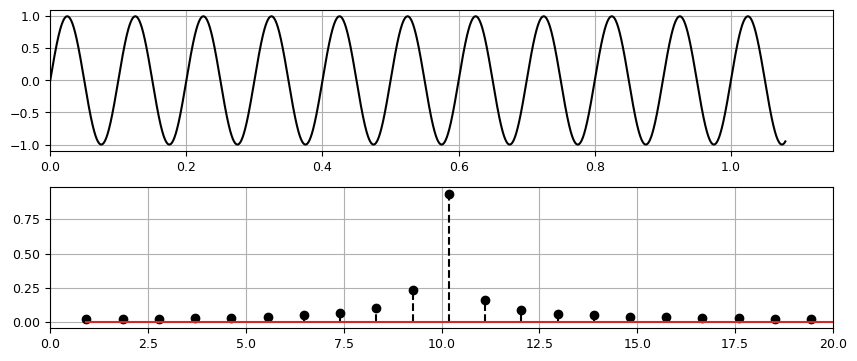

Ts * F0 =  10.9


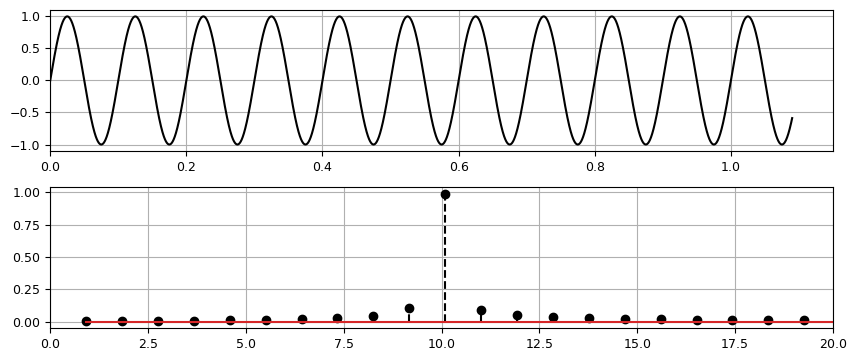

Ts * F0 =  11.0


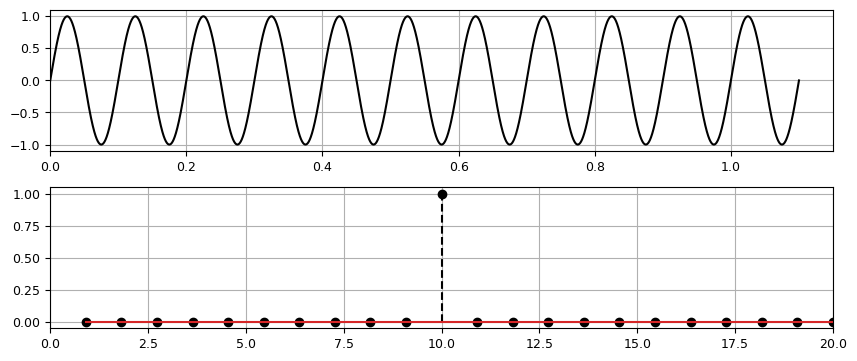

Ts * F0 =  11.100000000000001


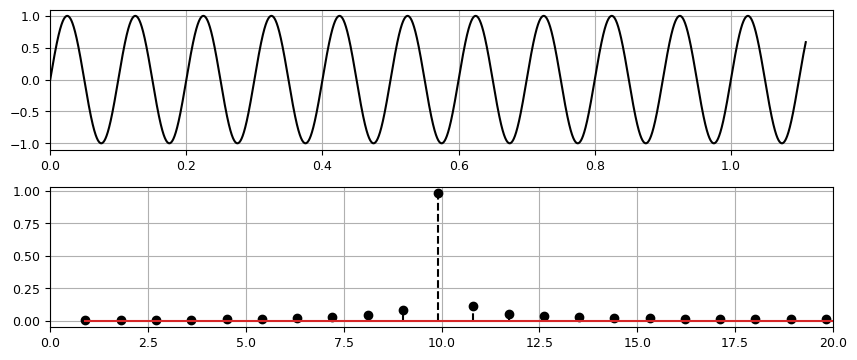

Ts * F0 =  11.200000000000001


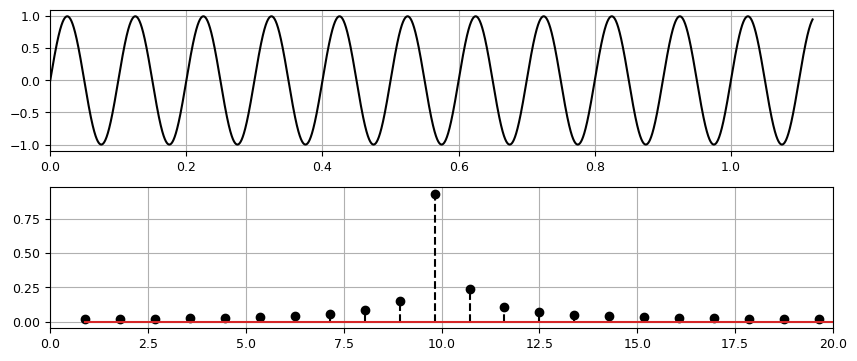

Ts * F0 =  11.3


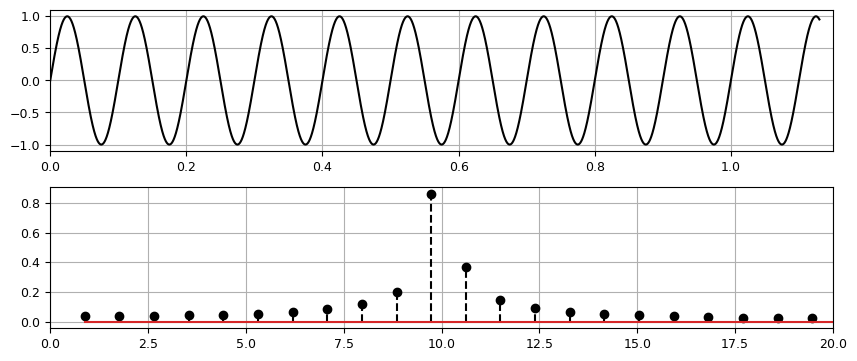

Ts * F0 =  11.400000000000002


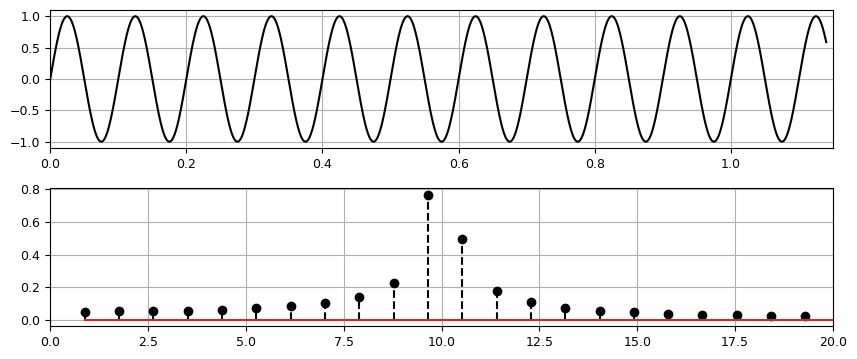

Ts * F0 =  11.5


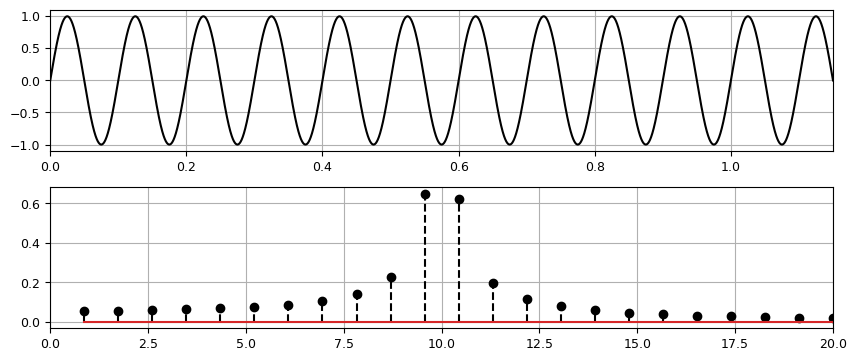

In [ ]:
# Ячейка № 2

# задание числа временных интервалов,
# на которых вычисляются значения
# анализируемого сигнала
k = 16

# задание числа узлов временной сетки,
# в узлах которой вычисляются значения
# анализируемого сигнала
L = 2**14

# инициализация массивов размерности k*L, используемых для
# хранения координат узлов текущей временной сетки (Time) и
# отсчетов анализируемого сигнала, вычисляемых на каждом
# из временных интервалов
Time = np.zeros([k, L])
u = np.zeros([k, L])

# задание значения числа информативных спектральных гармоник
L2 = round(L / 2) - 1

# задание значения частоту сигнала
Freq_S = 10

# вычисляем период сигнала
T_S = 1 / Freq_S

# инициализация массивов размерности k*L, используемых для хранения
# значений частот информативных спектральных гармоник (Freq_R)
# и соответствующих нормированных амплитуд,
# вычисленных на каждом из временных интервалах
Freq_R = np.zeros([k, L2])
c_R = np.zeros([k, L2])

for i in range(k):
    Tmax = 10 * T_S + 0.1 * T_S * i
    t = np.linspace(0, Tmax, L)
    dt = t[1] - t[0]
    for j in range(L):
        Time[i, j] = t[j]
        u[i, j] = np.sin(2 * np.pi * Freq_S * t[j])

    # вычисление значений комплекснозначных
    # коэффициентов ряда Фурье
    c = fft(u[i, :])

    # вычисление соответствующие значения
    # частот спектральных гармоник
    Freq = fftfreq(L, dt)

    # сохранение в массивы Freq_R, c_R
    # значения частот информативных спектральных гармоник
    # и соответствующих нормированных амплитуд
    for j in range(L2):
        Freq_R[i, j] = Freq[j + 1]
        c_R[i, j] = 2 * np.abs(c[j + 1]) / L

# визуализация зависимости анализируемых сигналов от времени
# и их спектры
for i in range(k):
    print("Ts * F0 = ", max(Time[i, :]) * Freq_S)
    # создаем графическое окно
    fig = plt.figure(figsize=(8.5, 7))

    # задаем размер шрифта, используемого для
    # нумерации делений на координатных осях
    plt.rcParams.update({"font.size": 9})

    # визуализация анализируемый сигнал
    ax = fig.add_subplot(4, 1, 1)
    ax.plot(Time[i, :], u[i, :], color="black")
    plt.xlim([0, Tmax])
    # включаем основную сетку
    plt.grid(which="major")
    # включаем дополнительную сетку
    plt.grid(which="minor", linestyle=":")
    plt.tight_layout()

    # визуализация амплитудный спектр
    # анализируемого сигнала
    ax = fig.add_subplot(4, 1, 2)
    ax.stem(Freq_R[i, :], c_R[i, :], "--k")
    # включаем основную сетку
    plt.grid(which="major")
    # включаем дополнительную сетку
    plt.grid(which="minor", linestyle=":")
    plt.tight_layout()
    plt.xlim([0, 20])

    plt.show()


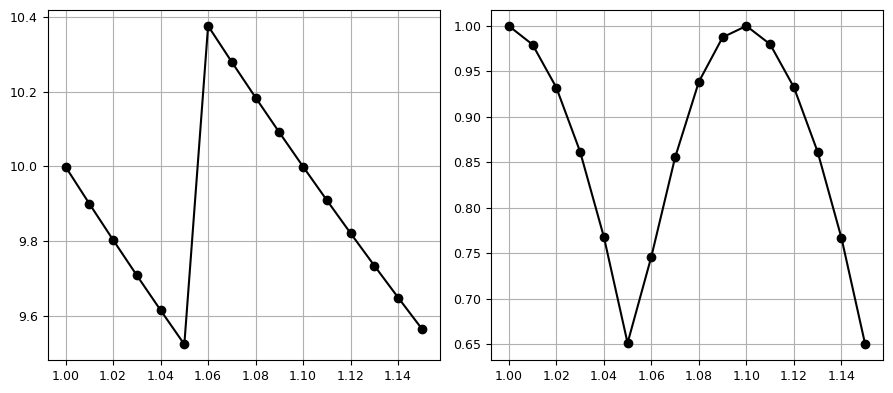

In [3]:
# Ячейка № 3

# инициализация массивов,
# используемых для хранения значений
# максимального коэффициента ДПФ (массив Q),
# значений частоты базисной функции,
# имеющей максимальную амплитуду,
# длительности данного временного интервала
Q = np.zeros(k)
Freq_max = np.zeros(k)
T_max = np.zeros(k)

# вычисление на каждом временном интервале
# максимального коэффициента ДПФ (массив Q),
# значения частоты базисной функции,
# имеющей максимальную амплитуду,
# и сохранение значения длительности
#  данного временного интервала
for i in range(k):
    T_max[i] = max(Time[i, :])
    Q[i] = max(c_R[i, :])
    j = 0
    while ~(Q[i] == c_R[i, j]):
        j = j + 1
    Freq_max[i] = Freq_R[i, j]

# визуализация зависимости частоты спектральной гармоники,
# имеющей максимальную амплитуду, и максимального значения
# модуля коэффициента ДПФ анализируемого сигнала
# от длительности интервала анализа
fig = plt.figure(figsize=(9, 4))
plt.rcParams.update({"font.size": 9})

# визуализация зависимости частоты спектральной гармоники,
# имеющей максимальную амплитуду,
# от длительности интервала анализа
ax = fig.add_subplot(1, 2, 2)
ax.plot(T_max, Q, "-o", color="black")
# включаем основную сетку
plt.grid(which="major")
# включаем дополнительную сетку
plt.grid(which="minor", linestyle=":")
plt.tight_layout()

# визуализация зависимости максимального значения
# модуля коэффициента ДПФ анализируемого сигнала
# от длительности интервала анализа
plt.rcParams.update({"font.size": 9})
ax = fig.add_subplot(1, 2, 1)
ax.plot(T_max, Freq_max, "-o", color="black")
# включение основной сетки
plt.grid(which="major")
# включение дополнительной сетки
plt.grid(which="minor", linestyle=":")
plt.tight_layout()

plt.show()